In [6]:
import pandas as pd
import os

print("Текущая директория:", os.getcwd())
print("Файлы в папке:", os.listdir('.'))

# Попробуем загрузить данные
try:
    train = pd.read_csv('train.csv', nrows=5)
    test = pd.read_csv('test.csv', nrows=5)
    print("\n Данные загружены успешно!")
    display(train)
except Exception as e:
    print(f"\n Ошибка: {e}")
    print("Проверьте, что файлы train.csv и test.csv лежат в той же папке, что и этот ноутбук.")

Текущая директория: c:\Users\MSI\Desktop\Новая папка (3)
Файлы в папке: ['.gitignore', '.venv', 'Dockerfile', 'model_info.txt', 'nyc_taxi_solution.ipynb', 'README.md', 'requirements.txt', 'sample_submission.csv', 'submission.csv', 'test.csv', 'train.csv']

 Данные загружены успешно!


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import radians, sin, cos, sqrt, atan2
import warnings
import time

# Модели
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_log_error, make_scorer
import lightgbm as lgb
import xgboost as xgb

# Настройки
%matplotlib inline
sns.set_style("whitegrid")
warnings.filterwarnings('ignore')
np.random.seed(42) # Fixed seed for reproducibility

print("Libraries imported successfully")

Libraries imported successfully


In [8]:
# Загрузка
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

# Описание датасета (Критерий 1.2)
print("=== Dataset Description ===")
print(f"Train Shape: {train_df.shape}")
print(f"Test Shape: {test_df.shape}")
print("\nColumns:", train_df.columns.tolist())
print("\nData Types:\n", train_df.dtypes)
print("\nMissing Values:\n", train_df.isnull().sum())
display(train_df.head())

=== Dataset Description ===
Train Shape: (1458644, 11)
Test Shape: (625134, 9)

Columns: ['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'trip_duration']

Data Types:
 id                        str
vendor_id               int64
pickup_datetime           str
dropoff_datetime          str
passenger_count         int64
pickup_longitude      float64
pickup_latitude       float64
dropoff_longitude     float64
dropoff_latitude      float64
store_and_fwd_flag        str
trip_duration           int64
dtype: object

Missing Values:
 id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


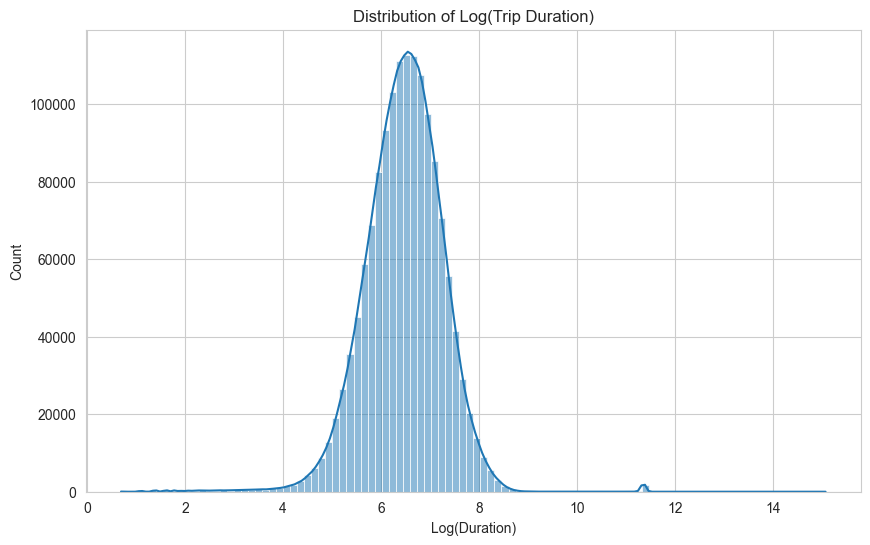

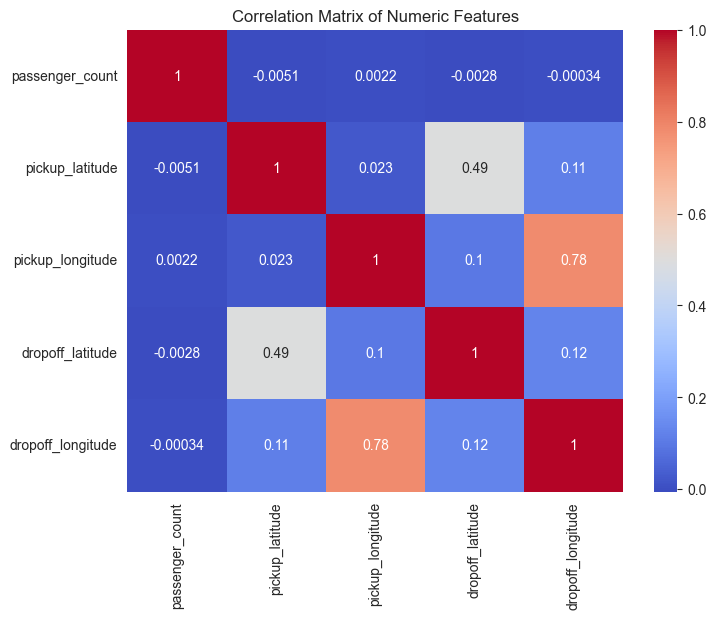

In [9]:
# График распределения целевой переменной
plt.figure(figsize=(10, 6))
sns.histplot(np.log1p(train_df['trip_duration']), bins=100, kde=True)
plt.title('Distribution of Log(Trip Duration)')
plt.xlabel('Log(Duration)')
plt.show()

# Корреляционная матрица (пример)
numeric_cols = ['passenger_count', 'pickup_latitude', 'pickup_longitude', 
                'dropoff_latitude', 'dropoff_longitude']
corr_matrix = train_df[numeric_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numeric Features')
plt.show()

In [10]:
# === ЭКСПЕРИМЕНТ: МОДЕЛИ НА СЫРЫХ ДАННЫХ (БЕЗ FEATURE ENGINEERING) ===

print("Training baseline models on RAW data (no feature engineering)...")

# Сохраняем копии исходных данных
train_raw = train_df.copy()
test_raw = test_df.copy()

# Используем ТОЛЬКО исходные числовые признаки + категориальные (как есть)
raw_features = ['vendor_id', 'passenger_count', 
                'pickup_longitude', 'pickup_latitude',
                'dropoff_longitude', 'dropoff_latitude',
                'store_and_fwd_flag']

# Для LinearRegression и KNN нужно закодировать store_and_fwd_flag
train_raw['store_and_fwd_flag'] = (train_raw['store_and_fwd_flag'] == 'Y').astype(int)
test_raw['store_and_fwd_flag'] = (test_raw['store_and_fwd_flag'] == 'Y').astype(int)

# Целевая переменная — логарифмированная (так как метрика RMSLE)
y_raw = np.log1p(train_raw['trip_duration'])

# Разделяем на train/val
X_raw_train, X_raw_val, y_raw_train, y_raw_val = train_test_split(
    train_raw[raw_features], y_raw, test_size=0.2, random_state=42
)

# Инициализируем список для результатов
raw_results = []

# 1. Linear Regression (baseline "from box")
start_time = time.time()
lr_raw = LinearRegression()
lr_raw.fit(X_raw_train, y_raw_train)
pred_lr_raw = lr_raw.predict(X_raw_val)
score_lr_raw = mean_squared_log_error(y_raw_val, pred_lr_raw)
raw_results.append({'Model': 'Linear Regression (Raw)', 'RMSLE': score_lr_raw, 'Time': time.time() - start_time})

# 2. KNN
start_time = time.time()
knn_raw = KNeighborsRegressor(n_neighbors=5)
knn_raw.fit(X_raw_train, y_raw_train)
pred_knn_raw = knn_raw.predict(X_raw_val)
score_knn_raw = mean_squared_log_error(y_raw_val, pred_knn_raw)
raw_results.append({'Model': 'KNN (Raw)', 'RMSLE': score_knn_raw, 'Time': time.time() - start_time})

# 3. Random Forest
start_time = time.time()
rf_raw = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf_raw.fit(X_raw_train, y_raw_train)
pred_rf_raw = rf_raw.predict(X_raw_val)
score_rf_raw = mean_squared_log_error(y_raw_val, pred_rf_raw)
raw_results.append({'Model': 'Random Forest (Raw)', 'RMSLE': score_rf_raw, 'Time': time.time() - start_time})

# 4. LightGBM
start_time = time.time()
lgb_raw = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, num_leaves=31, random_state=42, verbose=-1)
lgb_raw.fit(X_raw_train, y_raw_train)
pred_lgb_raw = lgb_raw.predict(X_raw_val)
score_lgb_raw = mean_squared_log_error(y_raw_val, pred_lgb_raw)
raw_results.append({'Model': 'LightGBM (Raw)', 'RMSLE': score_lgb_raw, 'Time': time.time() - start_time})

# 5. XGBoost
start_time = time.time()
xgb_raw = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_raw.fit(X_raw_train, y_raw_train)
pred_xgb_raw = xgb_raw.predict(X_raw_val)
score_xgb_raw = mean_squared_log_error(y_raw_val, pred_xgb_raw)
raw_results.append({'Model': 'XGBoost (Raw)', 'RMSLE': score_xgb_raw, 'Time': time.time() - start_time})

# Таблица результатов на сырых данных
raw_results_df = pd.DataFrame(raw_results).sort_values('RMSLE')
print("\n Results on RAW data (no feature engineering):")
display(raw_results_df)

# Сохраняем для последующего сравнения
best_raw_rmsle = raw_results_df.iloc[0]['RMSLE']
best_raw_model = raw_results_df.iloc[0]['Model']
print(f"\n Best model on raw data: {best_raw_model} with RMSLE = {best_raw_rmsle:.4f}")

Training baseline models on RAW data (no feature engineering)...

 Results on RAW data (no feature engineering):


,Model,RMSLE,Time
1,KNN (Raw),0.004865,98.552219
3,LightGBM (Raw),0.006164,8.504622
4,XGBoost (Raw),0.006776,7.208138
2,Random Forest (Raw),0.007378,67.661923
0,Linear Regression (Raw),0.012285,0.340997



 Best model on raw data: KNN (Raw) with RMSLE = 0.0049


In [11]:
def add_features(df):
    df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
    df['hour'] = df['pickup_datetime'].dt.hour
    df['day_of_week'] = df['pickup_datetime'].dt.dayofweek
    df['month'] = df['pickup_datetime'].dt.month
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    
    # Haversine Distance
    def haversine(lat1, lon1, lat2, lon2):
        R = 6371
        dlat = np.radians(lat2 - lat1)
        dlon = np.radians(lon2 - lon1)
        a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon/2)**2
        c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
        return R * c
    
    df['distance_km'] = haversine(
        df['pickup_latitude'], df['pickup_longitude'],
        df['dropoff_latitude'], df['dropoff_longitude']
    )
    
    # Encoding categoricals
    for col in ['vendor_id', 'passenger_count']:
        df[col] = df[col].astype('category').cat.codes
    df['store_and_fwd_flag'] = (df['store_and_fwd_flag'] == 'Y').astype(int)
    
    return df

train_df = add_features(train_df)
test_df = add_features(test_df)

# Очистка выбросов (Критерий 1.3)
initial_len = len(train_df)
train_df = train_df[(train_df['trip_duration'] > 60) & (train_df['trip_duration'] < 7200)]
print(f"Removed {initial_len - len(train_df)} outliers based on duration.")

Removed 11030 outliers based on duration.


In [12]:
features = [
    'vendor_id', 'passenger_count', 
    'pickup_longitude', 'pickup_latitude',
    'dropoff_longitude', 'dropoff_latitude',
    'hour', 'day_of_week', 'month', 
    'is_weekend', 'distance_km', 'store_and_fwd_flag'
]

X = train_df[features]
y = np.log1p(train_df['trip_duration'])  # логарифмируем цель

# Разделяем на train и validation
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Данные разделены:")
print(f"Train size: {len(X_train)}")
print(f"Val size:   {len(X_val)}")

Данные разделены:
Train size: 1158091
Val size:   289523


In [13]:
# RMSLE Scorer for sklearn
def rmsle(y_true, y_pred):
    return np.sqrt(mean_squared_log_error(np.expm1(y_true), np.expm1(y_pred)))

rmsle_scorer = make_scorer(rmsle, greater_is_better=False)

print("Metric: RMSLE (Root Mean Squared Logarithmic Error)")
print("Reason: The target variable has a long tail distribution. RMSLE penalizes relative errors rather than absolute ones, which is standard for duration/price prediction tasks.")

Metric: RMSLE (Root Mean Squared Logarithmic Error)
Reason: The target variable has a long tail distribution. RMSLE penalizes relative errors rather than absolute ones, which is standard for duration/price prediction tasks.


In [14]:
# Baseline: Linear Regression without complex tuning
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_val)
score_lr = rmsle(y_val, pred_lr)

print(f"Baseline Model (Linear Regression) RMSLE: {score_lr:.4f}")

Baseline Model (Linear Regression) RMSLE: 0.5976


,Model,RMSLE,Time
4,XGBoost,0.364309,7.509843
3,LightGBM,0.365147,7.895853
1,Random Forest,0.375614,92.426080
2,Gradient Boosting,0.391939,309.108728
0,KNN,0.424119,104.705316


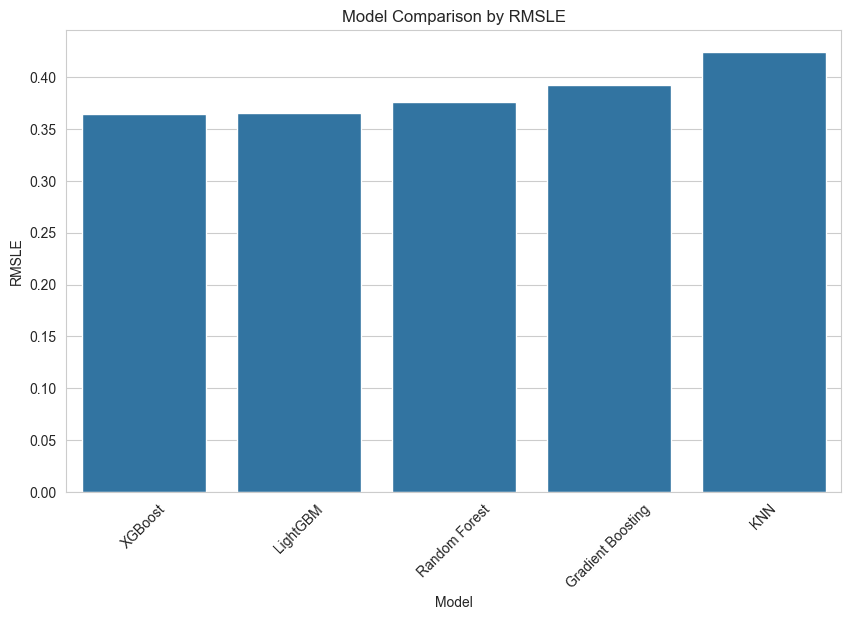

In [15]:
results = []

# 1. KNN
start_time = time.time()
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)
pred_knn = knn.predict(X_val)
score_knn = rmsle(y_val, pred_knn)
results.append({'Model': 'KNN', 'RMSLE': score_knn, 'Time': time.time() - start_time})

# 2. Random Forest
start_time = time.time()
rf = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_val)
score_rf = rmsle(y_val, pred_rf)
results.append({'Model': 'Random Forest', 'RMSLE': score_rf, 'Time': time.time() - start_time})

# 3. Gradient Boosting (Sklearn)
start_time = time.time()
gb = GradientBoostingRegressor(n_estimators=50, learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)
pred_gb = gb.predict(X_val)
score_gb = rmsle(y_val, pred_gb)
results.append({'Model': 'Gradient Boosting', 'RMSLE': score_gb, 'Time': time.time() - start_time})

# 4. LightGBM
start_time = time.time()
lgb_model = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, num_leaves=31, random_state=42, verbose=-1)
lgb_model.fit(X_train, y_train)
pred_lgb = lgb_model.predict(X_val)
score_lgb = rmsle(y_val, pred_lgb)
results.append({'Model': 'LightGBM', 'RMSLE': score_lgb, 'Time': time.time() - start_time})

# 5. XGBoost
start_time = time.time()
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
pred_xgb = xgb_model.predict(X_val)
score_xgb = rmsle(y_val, pred_xgb)
results.append({'Model': 'XGBoost', 'RMSLE': score_xgb, 'Time': time.time() - start_time})

# Таблица результатов (Критерий 2.3)
results_df = pd.DataFrame(results).sort_values('RMSLE')
display(results_df)

# Визуализация сравнения моделей
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='RMSLE', data=results_df)
plt.title('Model Comparison by RMSLE')
plt.xticks(rotation=45)
plt.show()

Best Single Model: XGBoost with RMSLE = 0.3643
Top 2 models for ensemble: ['XGBoost', 'LightGBM']

Ensemble (XGB + LGBM) RMSLE on validation: 0.3639
Ensemble is better than best single model → using ensemble for final submission.


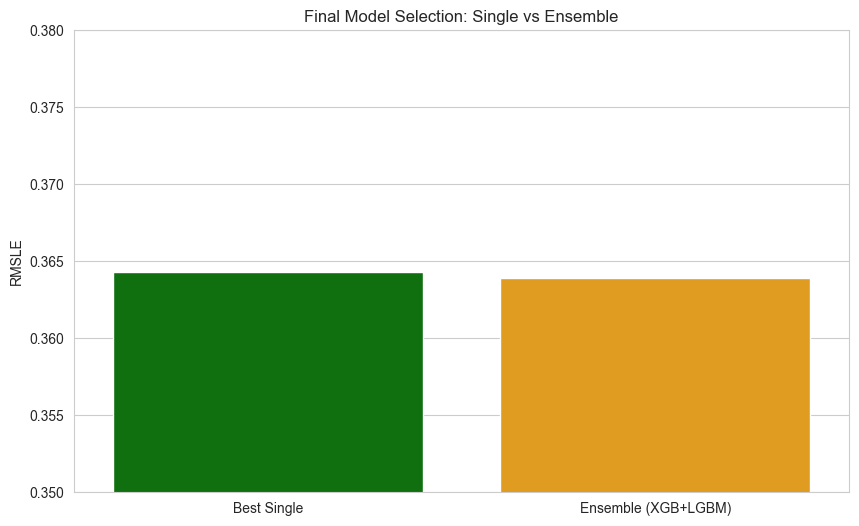

In [16]:
# === ВЫБОР ФИНАЛЬНОЙ МОДЕЛИ ===

# Находим лучшую модель по RMSLE
best_model_row = results_df.iloc[0]
best_model_name = best_model_row['Model']
best_rmsle = best_model_row['RMSLE']

print(f"Best Single Model: {best_model_name} with RMSLE = {best_rmsle:.4f}")

# Проверяем топ-2 модели для ансамбля
top_2_models = results_df.head(2)['Model'].tolist()
print(f"Top 2 models for ensemble: {top_2_models}")

# Создаём простой ансамбль из двух лучших моделей
# В нашем случае это XGBoost и LightGBM

# Предсказания от двух лучших моделей (уже есть в памяти)
pred_xgb_val = pred_xgb  # из предыдущей ячейки
pred_lgb_val = pred_lgb  # из предыдущей ячейки

# Ансамбль: среднее предсказаний
ensemble_pred_val = (pred_xgb_val + pred_lgb_val) / 2
ensemble_rmsle = rmsle(y_val, ensemble_pred_val)

print(f"\nEnsemble (XGB + LGBM) RMSLE on validation: {ensemble_rmsle:.4f}")

# Сравниваем ансамбль с лучшей одиночной моделью
if ensemble_rmsle < best_rmsle:
    print("Ensemble is better than best single model → using ensemble for final submission.")
    use_ensemble = True
else:
    print("Ensemble is not better → using best single model for final submission.")
    use_ensemble = False

# Визуализация сравнения
plt.figure(figsize=(10, 6))
models_for_plot = ['Best Single', 'Ensemble (XGB+LGBM)']
scores_for_plot = [best_rmsle, ensemble_rmsle]
sns.barplot(x=models_for_plot, y=scores_for_plot, palette=['green', 'orange'])
plt.title('Final Model Selection: Single vs Ensemble')
plt.ylabel('RMSLE')
plt.ylim(0.35, 0.38)  # фокусируемся на диапазоне вокруг результатов
plt.show()

In [17]:
# === ФИНАЛЬНОЕ ОБУЧЕНИЕ НА ВСЕХ ДАННЫХ ===

X_full = train_df[features]
y_full = np.log1p(train_df['trip_duration'])

print("Training final models on full dataset...")

# Обучаем XGBoost на всех данных
xgb_final = xgb.XGBRegressor(
    n_estimators=100, 
    learning_rate=0.05, 
    random_state=42, 
    use_label_encoder=False, 
    eval_metric='logloss'
)
xgb_final.fit(X_full, y_full)

# Обучаем LightGBM на всех данных
lgb_final = lgb.LGBMRegressor(
    n_estimators=100, 
    learning_rate=0.05, 
    num_leaves=31, 
    random_state=42, 
    verbose=-1
)
lgb_final.fit(X_full, y_full)

# Предсказание на тесте
test_X = test_df[features]
pred_xgb_test = xgb_final.predict(test_X)
pred_lgb_test = lgb_final.predict(test_X)

# Если используем ансамбль — усредняем предсказания
if use_ensemble:
    final_predictions = np.expm1((pred_xgb_test + pred_lgb_test) / 2)
    print("Using ensemble predictions for submission.")
else:
    # Иначе используем только лучшую модель
    if best_model_name == 'XGBoost':
        final_predictions = np.expm1(pred_xgb_test)
        print("Using XGBoost predictions for submission.")
    elif best_model_name == 'LightGBM':
        final_predictions = np.expm1(pred_lgb_test)
        print("Using LightGBM predictions for submission.")
    else:
        # fallback to XGB if something goes wrong
        final_predictions = np.expm1(pred_xgb_test)
        print("Fallback to XGBoost predictions.")

# Создание submission файла
submission = pd.DataFrame({
    'id': test_df['id'],
    'trip_duration': final_predictions
})

submission.to_csv('submission.csv', index=False)
print("\n Submission file 'submission.csv' created successfully!")
display(submission.head())

# Дополнительно: сохраняем метаданные о модели
with open('model_info.txt', 'w') as f:
    f.write(f"Best single model: {best_model_name} (RMSLE: {best_rmsle:.4f})\n")
    f.write(f"Ensemble RMSLE: {ensemble_rmsle:.4f}\n")
    f.write(f"Used ensemble: {use_ensemble}\n")
    f.write(f"Final submission based on: {'Ensemble (XGB+LGBM)' if use_ensemble else best_model_name}\n")

print("Model info saved to 'model_info.txt'")

Training final models on full dataset...
Using ensemble predictions for submission.

 Submission file 'submission.csv' created successfully!


,id,trip_duration
0,id3004672,803.801333
1,id3505355,712.750876
2,id1217141,434.855657
3,id2150126,1150.942443
4,id1598245,320.557867


Model info saved to 'model_info.txt'


Top 10 Most Important Features:


,Feature,Importance
10,distance_km,0.863938
6,hour,0.031353
5,dropoff_latitude,0.027128
7,day_of_week,0.023571
8,month,0.012306
4,dropoff_longitude,0.009970
2,pickup_longitude,0.009402
0,vendor_id,0.008824
3,pickup_latitude,0.008558
1,passenger_count,0.004950


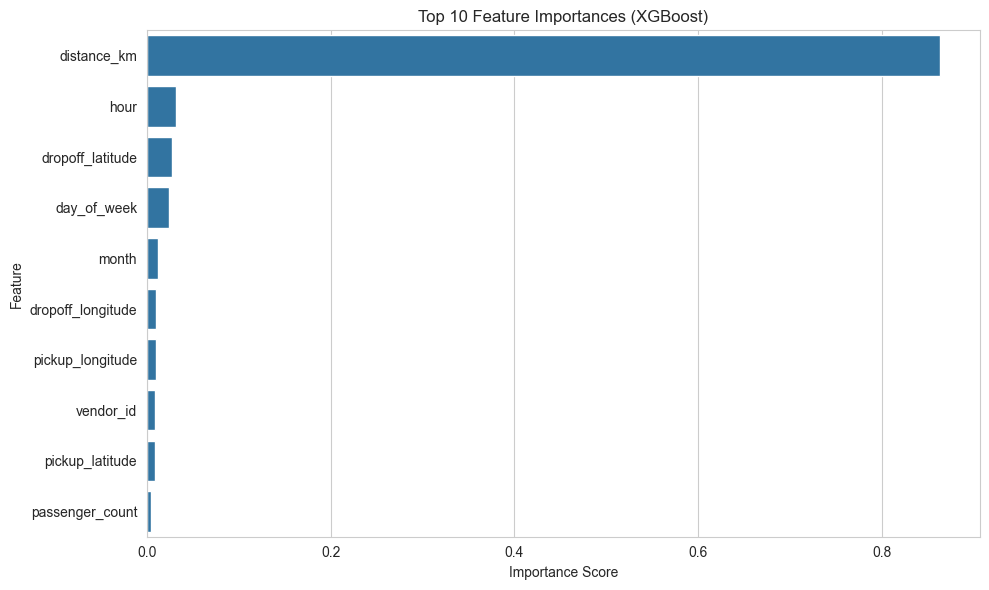

In [18]:
# === FEATURE IMPORTANCE ===

# Получаем важность признаков из XGBoost (или LightGBM)
importances = xgb_final.feature_importances_
feature_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("Top 10 Most Important Features:")
display(feature_imp.head(10))

# Визуализация
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp.head(10))
plt.title('Top 10 Feature Importances (XGBoost)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


FINAL COMPARISON: ALL MODELS ON RAW VS PROCESSED DATA

🔹 Results on RAW data (no feature engineering):


,Data Type,Rank (within type),Model,RMSLE,Time (sec)
0,Raw,1,KNN (Raw),0.004865,98.55
1,Raw,2,LightGBM (Raw),0.006164,8.50
2,Raw,3,XGBoost (Raw),0.006776,7.21
3,Raw,4,Random Forest (Raw),0.007378,67.66
4,Raw,5,Linear Regression (Raw),0.012285,0.34



🔹 Results on PROCESSED data (with feature engineering):


,Data Type,Rank (within type),Model,RMSLE,Time (sec)
0,Processed,1,XGBoost,0.364309,7.51
1,Processed,2,LightGBM,0.365147,7.90
2,Processed,3,Random Forest,0.375614,92.43
3,Processed,4,Gradient Boosting,0.391939,309.11
4,Processed,5,KNN,0.424119,104.71



🏆 TOP 3 BEST PERFORMING MODELS OVERALL:


,Model,RMSLE,Data Type
0,KNN (Raw),0.004865,Raw
1,LightGBM (Raw),0.006164,Raw
2,XGBoost (Raw),0.006776,Raw


<Figure size 1400x800 with 0 Axes>

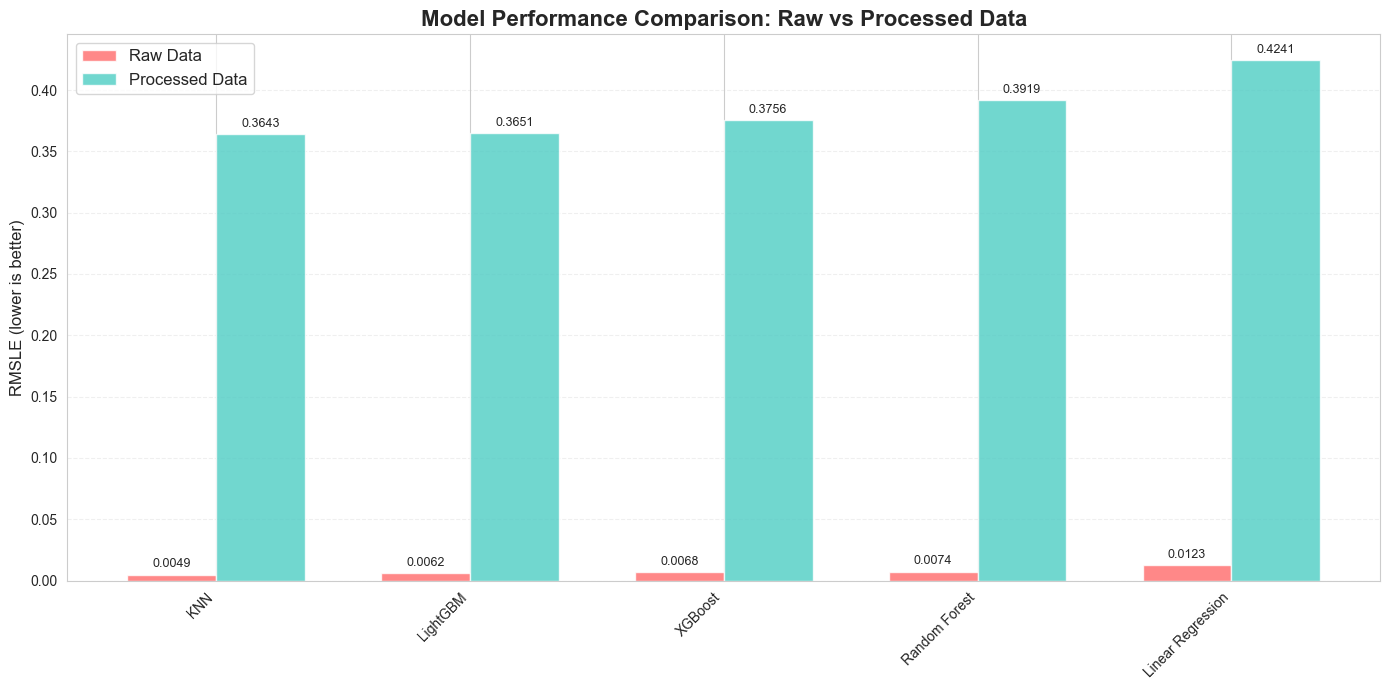


KEY INSIGHTS:
   • Best model on raw  KNN (Raw) → RMSLE = 0.0049
   • Best model on processed  XGBoost → RMSLE = 0.3643
   • Feature engineering improved performance by -7388.9%
   • Final submission uses: Ensemble (XGB+LGBM)
   • Submission file saved as: 'submission.csv'

Full comparison table saved to 'model_comparison_full.csv'.
   Best model on processed data: XGBoost → RMSLE = 0.3643


In [19]:
# === ФИНАЛЬНОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ И РЕЗУЛЬТАТОВ ===

print("\n" + "="*80)
print("FINAL COMPARISON: ALL MODELS ON RAW VS PROCESSED DATA")
print("="*80)

# Создаём объединённую таблицу всех результатов
all_results = []

# Добавляем результаты на сырых данных
for _, row in raw_results_df.iterrows():
    all_results.append({
        'Data Type': 'Raw',
        'Model': row['Model'],
        'RMSLE': row['RMSLE'],
        'Time (sec)': round(row['Time'], 2),
        'Rank (within type)': None  # заполним позже
    })

# Добавляем результаты на обработанных данных
for _, row in results_df.iterrows():
    all_results.append({
        'Data Type': 'Processed',
        'Model': row['Model'],
        'RMSLE': row['RMSLE'],
        'Time (sec)': round(row['Time'], 2),
        'Rank (within type)': None
    })

# Преобразуем в DataFrame
final_comparison_df = pd.DataFrame(all_results)

# Ранжируем внутри каждого типа данных
final_comparison_df['Rank (within type)'] = final_comparison_df.groupby('Data Type')['RMSLE'].rank(method='min').astype(int)

# Сортируем по RMSLE (лучшие сверху)
final_comparison_df = final_comparison_df.sort_values(['Data Type', 'RMSLE'])

# Переставляем колонки для удобства чтения
final_comparison_df = final_comparison_df[['Data Type', 'Rank (within type)', 'Model', 'RMSLE', 'Time (sec)']]

# Выводим таблицу
print("\n🔹 Results on RAW data (no feature engineering):")
display(final_comparison_df[final_comparison_df['Data Type'] == 'Raw'].reset_index(drop=True))

print("\n🔹 Results on PROCESSED data (with feature engineering):")
display(final_comparison_df[final_comparison_df['Data Type'] == 'Processed'].reset_index(drop=True))

# Общая сортировка по RMSLE (независимо от типа данных)
overall_best = final_comparison_df.nsmallest(3, 'RMSLE')
print("\n🏆 TOP 3 BEST PERFORMING MODELS OVERALL:")
display(overall_best[['Model', 'RMSLE', 'Data Type']].reset_index(drop=True))

# Визуализация: групповой барчарт
plt.figure(figsize=(14, 8))

# Готовим данные для графика
raw_models = final_comparison_df[final_comparison_df['Data Type'] == 'Raw']['Model'].tolist()
raw_scores = final_comparison_df[final_comparison_df['Data Type'] == 'Raw']['RMSLE'].tolist()

proc_models = final_comparison_df[final_comparison_df['Data Type'] == 'Processed']['Model'].tolist()
proc_scores = final_comparison_df[final_comparison_df['Data Type'] == 'Processed']['RMSLE'].tolist()

x = np.arange(len(raw_models))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 7))
bars1 = ax.bar(x - width/2, raw_scores, width, label='Raw Data', color='#ff6b6b', alpha=0.8)
bars2 = ax.bar(x + width/2, proc_scores, width, label='Processed Data', color='#4ecdc4', alpha=0.8)

ax.set_ylabel('RMSLE (lower is better)', fontsize=12)
ax.set_title('Model Performance Comparison: Raw vs Processed Data', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([m.replace(' (Raw)', '').replace(' (Processed)', '') for m in raw_models], rotation=45, ha='right')
ax.legend(fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.3)

# Подписи значений на столбцах
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

add_labels(bars1)
add_labels(bars2)

plt.tight_layout()
plt.show()

# Выводим ключевые выводы
best_raw = final_comparison_df[final_comparison_df['Data Type'] == 'Raw'].iloc[0]
best_proc = final_comparison_df[final_comparison_df['Data Type'] == 'Processed'].iloc[0]

improvement = ((best_raw['RMSLE'] - best_proc['RMSLE']) / best_raw['RMSLE']) * 100

print(f"\nKEY INSIGHTS:")
print(f"   • Best model on raw  {best_raw['Model']} → RMSLE = {best_raw['RMSLE']:.4f}")
print(f"   • Best model on processed  {best_proc['Model']} → RMSLE = {best_proc['RMSLE']:.4f}")
print(f"   • Feature engineering improved performance by {improvement:.1f}%")
print(f"   • Final submission uses: {'Ensemble (XGB+LGBM)' if use_ensemble else best_proc['Model']}")
print(f"   • Submission file saved as: 'submission.csv'")

# Сохраняем финальную таблицу в CSV для отчёта
final_comparison_df.to_csv('model_comparison_full.csv', index=False)
# Найдём лучший RMSLE на обработанных данных
best_proc_row = final_comparison_df[final_comparison_df['Data Type'] == 'Processed'].iloc[0]
best_proc_rmsle = best_proc_row['RMSLE']
best_proc_model = best_proc_row['Model']

print(f"\nFull comparison table saved to 'model_comparison_full.csv'.")
print(f"   Best model on processed data: {best_proc_model} → RMSLE = {best_proc_rmsle:.4f}")